<br>

# BASES VECTORIALES

Las bases vectoriales es una tecnología que ya tiene tiempo de desarrollo pero que encontro su auge con el uso de embeddings.
Son sistemas de indexación y recuperación espacial, y sobre esta base se construye su utilidad.


Esto se debe a que los motores de busqueda de bases de datos mas tradicionales como relacionales o NoSQL utilizan busquedas por coincidencia exacta.
Si bien podemos usar operadores regex, LIKE, y comparadores. El funcionamiento por atras sigue siendo el mismo, una comparación registro a registro con los valores esperados (pueden ser unicos o dentro de un rango).

<br>

Entonces la primer pregunta que nace es *¿Que es lo que busca un motor de busqueda de una base vectorial?*

Como bien dice el nombre, **vectores**, y sin volar mucho podemos recordar que los embeddings son representaciones vectoriales de alta dimencionalidad de objetos como texto,imagenes,o sonido. Entonces sabemos que podemos guardar objetos en forma de vectores.

<br>

¿Cual es la utilidad de guardar un vector?

Si dijimos que un embedding permite hacer una descripción de caracteristicas que definen a un objeto, entonces lo que tenemos guardado en una base de datos vectorial son caracteristicas que definen a un objeto, y como ya vimos antes estas caracteristicas pueden ser operadas algebraicamente para obtener distancias, diferencias ,e incluso inferir nuevos objetos a partir de la operacion algebraica de otros objetos.



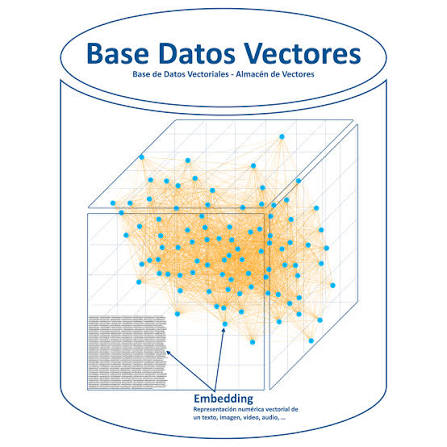


<br>

<br>

##**El Paradigma Vectorial**: La Proximidad en el Espacio (Probabilístico)


Una base de datos vectorial no entiende de letras, strings, fechas o booleanos en su núcleo; entiende de distancias en un espacio geométrico de cientos o miles de dimensiones.

La consulta es un punto en el espacio: Cuando hacés una pregunta, esta se transforma en un vector (un punto en un mapa flotante).

La búsqueda es matemática analítica: La base de datos no busca "palabras clave" o "IDs de productos". Calcula qué tan cerca geométricamente están los otros puntos del punto de tu consulta.

El resultado es un orden de similitud: No te devuelve un "verdadero o falso", te devuelve una lista de elementos ordenados por una métrica de distancia (como la similitud coseno), acompañada de un porcentaje de confianza (ej. "Este elemento es un 94% cercano a tu consulta").

<br>



# VENTAJAS DEL USO DE BASES VECTORIALES


En la fase inicial de un proyecto de Inteligencia Artificial, es común y tentador almacenar los embeddings en una matriz local de NumPy o utilizar bases de datos relacionales convencionales con extensiones vectoriales (como pgvector en PostgreSQL).

Si bien estas opciones son válidas para prototipos o volúmenes pequeños de datos, presentan limitaciones críticas de rendimiento a gran escala.

<br>

Vamos a detallar las ventajas de arquitectura y rendimiento que ofrecen las bases de datos vectoriales nativas (como Pinecone, Milvus, Qdrant o Chroma).

<br>

- Búsqueda de similitud de alta velocidad (**Algoritmos ANN**)

Las bases de datos tradicionales buscan datos mediante coincidencias exactas (filtros WHERE, índices B-Tree). Los embeddings, en cambio, requieren calcular la distancia matemática (Coseno, Euclidiana o Producto Punto) entre un vector de consulta y millones de vectores almacenados.

La ventaja nativa: En lugar de realizar una búsqueda exacta de "fuerza bruta" (comparar contra absolutamente todos los vectores, lo cual destruiría el rendimiento en NumPy), las bases vectoriales utilizan algoritmos de Vecinos Más Cercanos Aproximados (**ANN**) como **HNSW** (Hierarchical Navigable Small World) o **IVF** (Inverted File Index).

Esto reduce el tiempo de búsqueda de un orden lineal $\mathcal{O}(N)$ a un orden logarítmico $\mathcal{O}(\log N)$, devolviendo resultados en milisegundos.

<br>

- Indexación avanzada y dinámica

En arquitecturas no nativas, recalcular un índice cuando ingresan nuevos datos puede bloquear la base de datos o requerir un procesamiento batch costoso.

La ventaja nativa: Los motores vectoriales están diseñados para construir y actualizar índices de alta dimensionalidad de forma incremental y eficiente.

Esto significa que la base de datos puede seguir respondiendo consultas de lectura a alta velocidad mientras indexa nuevos embeddings en tiempo real, manteniendo la consistencia de los datos sin degradar la experiencia del usuario.

<br>

- Escalabilidad horizontal y gestión de memoria

Una matriz de NumPy reside completamente en la memoria RAM del sistema.

Si tu volumen de embeddings supera la capacidad de la memoria, el sistema colapsa (Out of Memory).

La ventaja nativa: Están construidas con arquitecturas distribuidas de tipo Cloud-Native.

Permiten el sharding (fragmentación de datos) y la replicación a través de múltiples nodos. Además, gestionan de forma inteligente qué parte del índice debe residir en RAM para garantizar velocidad y qué parte puede mantenerse en almacenamiento persistente (**SSD/NVMe**), permitiendo manejar miles de millones de vectores de forma costo-eficiente.

<br>

- Procesamiento y mutabilidad en tiempo real

Muchas soluciones indexadas tradicionales sufren cuando los datos cambian constantemente (operaciones de inserción, actualización y borrado - CRUD).

La ventaja nativa: Garantizan operaciones CRUD en tiempo real.

Si un usuario borra un producto de un e-commerce o actualiza un documento en el sistema, el embedding correspondiente se elimina o actualiza en el índice vectorial de manera inmediata, evitando que las búsquedas semánticas devuelvan información obsoleta.


<br>

- Abstracción del soporte multimodal

A nivel matemático, un embedding es simplemente un vector, sin importar si proviene de un texto, un clip de audio, una imagen médica o un video.

La ventaja nativa: Al unificar todo bajo la estructura de vectores, las bases de datos vectoriales rompen las barreras de los formatos de archivos tradicionales.

Permiten realizar búsquedas cruzadas (por ejemplo, ingresar el embedding de un texto mediante un modelo como CLIP y encontrar embeddings de imágenes similares) dentro del mismo índice y con la misma infraestructura, simplificando drásticamente la arquitectura del software.

<br>

- Filtrado híbrido para análisis avanzado

En aplicaciones reales (como sistemas de recomendación o arquitecturas RAG), rara vez se busca solo por similitud vectorial; a menudo se necesita combinar el contexto con metadatos (ej. "buscar imágenes similares a esta, pero solo las subidas en los últimos 3 meses y que pertenezcan a la categoría 'Calzado'").

La ventaja nativa: Soportan filtrado híbrido (Pre-filtering o Post-filtering). Ejecutan de forma integrada la búsqueda semántica vectorial junto con filtros relacionales tradicionales sobre metadatos adjuntos al vector, algo que en matrices de NumPy requeriría programar lógica compleja y pesada a mano.

<br>

- Eficiencia en el uso de recursos mediante Cuantización

Almacenar millones de vectores de 1536 dimensiones en precisión flotante de 32 bits (float32) consume una cantidad masiva de almacenamiento y ancho de banda de memoria.

La ventaja nativa: Implementan técnicas nativas de Cuantización Escalar (**SQ**) o Cuantización de Producto (**PQ**).

Estas técnicas comprimen los vectores (por ejemplo, convirtiendo float32 a int8) reduciendo el uso de memoria hasta en un 70-80% con una pérdida casi imperceptible en la precisión de la búsqueda, optimizando drásticamente los costos de infraestructura.

<br>
<br>

### Comparativa de Infraestructura para el Almacenamiento de Embeddings

<br>

| Característica | Matriz NumPy / Local | BD Relacional (SQL + Extensión) | BD Vectorial Nativa |
| :--- | :--- | :--- | :--- |
| **Volumen de datos ideal** | Pequeño (Prototipos/Local) | Pequeño a Mediano | Masivo (Escala de producción) |
| **Complejidad de búsqueda** | $\mathcal{O}(N)$ (Lineal / Fuerza bruta) | Variable (Depende de la extensión) | $\mathcal{O}(\log N)$ (Aproximada / Ultra rápida) |
| **Gestión de Memoria RAM** | Crítica (Carga todo en memoria) | Moderada (Depende del motor de BD) | Optimizada (Paginación y Cuantización) |
| **Filtrado por Metadatos** | Manual (Lógica propia en código) | Excelente (Nativo de SQL) | Excelente (Filtrado Híbrido Integrado) |
| **Escalabilidad Horizontal** | Nula (Limitada al hardware local) | Compleja / Costosa | Nativa (*Cloud-Native / Sharding*) |

<br>
<br>

##Por qué esta característica cambia las reglas del juego?

Esta naturaleza espacial genera tres diferencias conceptuales inmediatas:

<br>

- Comprensión del Contexto (Semántica): Permite que el sistema devuelva resultados que son conceptualmente idénticos pero textualmente diferentes. Puede asociar la foto de un amanecer en la montaña con la frase escrita "paisaje natural matutino" porque sus vectores están cerca en el mapa, algo imposible para un índice tradicional.

<br>

- Tolerancia al "Ruido": Si una imagen está ligeramente pixelada, o si el texto tiene errores de ortografía, el vector resultante se moverá apenas unos milímetros en ese espacio multidimensional. El sistema seguirá encontrando el dato correcto porque prioriza la cercanía, no la perfección formal del dato.

<br>

- Algoritmos probabilísticos en el núcleo: Para poder recorrer mapas de miles de millones de puntos a toda velocidad, renuncian a la precisión matemática absoluta del 100% en favor de una velocidad descomunal, utilizando los algoritmos de Vecinos Más Cercanos Aproximados (ANN). Saben que en el mundo de la IA, es preferible obtener los 10 resultados más relevantes en 2 milisegundos que escanear todo el mapa de forma exacta y tardar 10 segundos.

<br>

**En resumen: mientras las bases tradicionales fueron creadas para administrar y estructurar datos precisos, las bases vectoriales nacieron para navegar y entender el significado de los datos.**


<br>

<br>


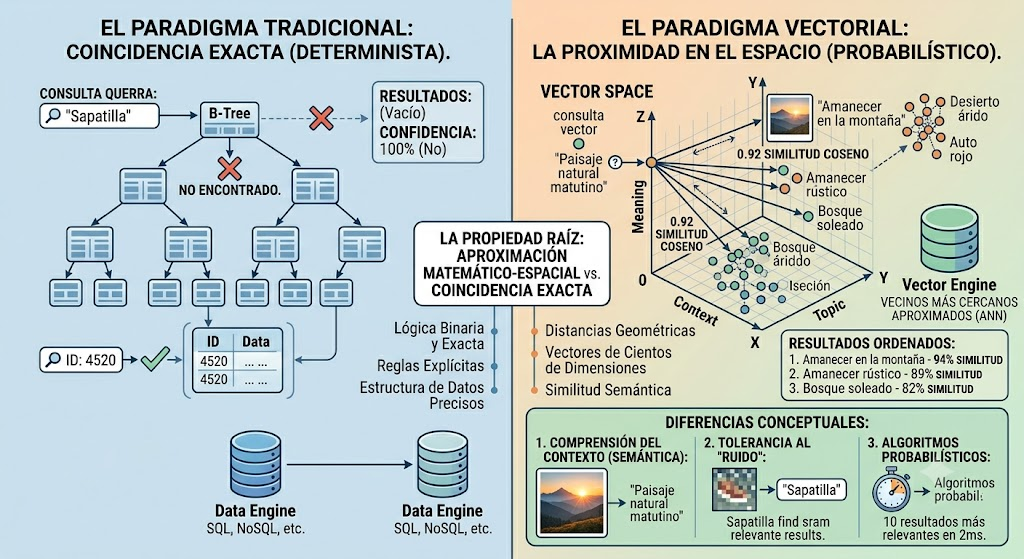

<br>

# CHROMADB

[Pagina Oficial de ChromaDB](https://www.trychroma.com/)

<br>

ChromaDB es una solución de base vectorial open source sumamente simple de utilizar, liviana, y que permite trabjaar a nivel de producción sin tener que escalar a tecnologias costosas.

<br>

- Integración sencilla: Se embebe directamente en el código de tus aplicaciones sin necesidad de configurar sistemas cliente-servidor para empezar a probar.

<br>

- Ligera y rápida: Permite realizar prototipos rápidos directamente desde una laptop, utilizando la memoria RAM o guardando los datos de forma persistente en SQLite.

<br>

- Todo en uno: Combina la búsqueda vectorial, la búsqueda de texto completo y el filtrado por metadatos (como fechas o autores) en una sola interfaz.

<br>

- Gestión automática de embeddings: Permite pasarle tus textos directamente y se encarga de convertirlos en vectores utilizando los modelos de lenguaje configurados.

<br>
<br>

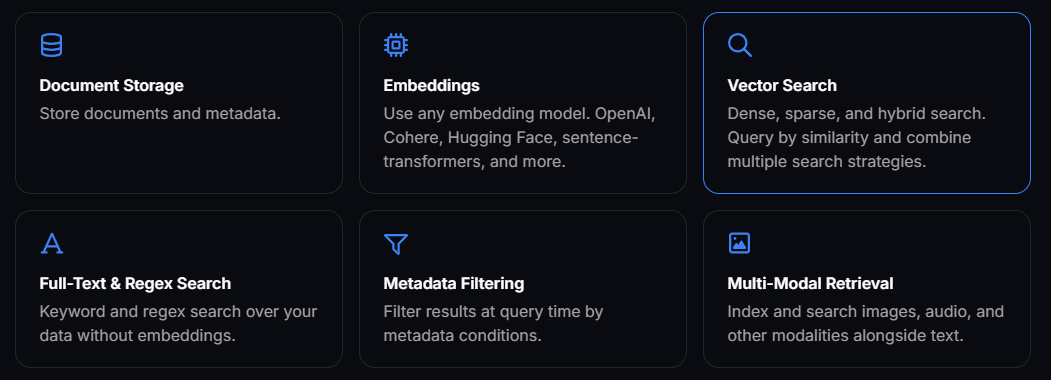

## Arquitectura Interna y Componentes

Internamente ChromaDB utiliza tres conceptos core:

<br>

- Colecciones (Collections):

<br>

 Es el equivalente a una "tabla" en SQL o una "colección" en MongoDB. Es donde se agrupan los vectores. Cada colección tiene un modelo de embedding asignado (ya sea el nativo, o uno de OpenAI, Hugging Face, Cohere, etc.).

<br>

- Documentos y Metadatos:

<br>

 Chroma permite guardar el vector junto con el texto original que lo generó (documents) y un diccionario de datos estructurados (metadatas), como el autor, la fecha o la URL.

<br>

- El Motor de Búsqueda:

<br>

 Por debajo, Chroma utiliza la librería hnswlib. Esto significa que su algoritmo de Vecinos Más Cercanos Aproximados (ANN) es HNSW (Hierarchical Navigable Small World), lo que garantiza búsquedas logarítmicas ultra rápidas incluso corriendo en hardware modesto.


<br>

 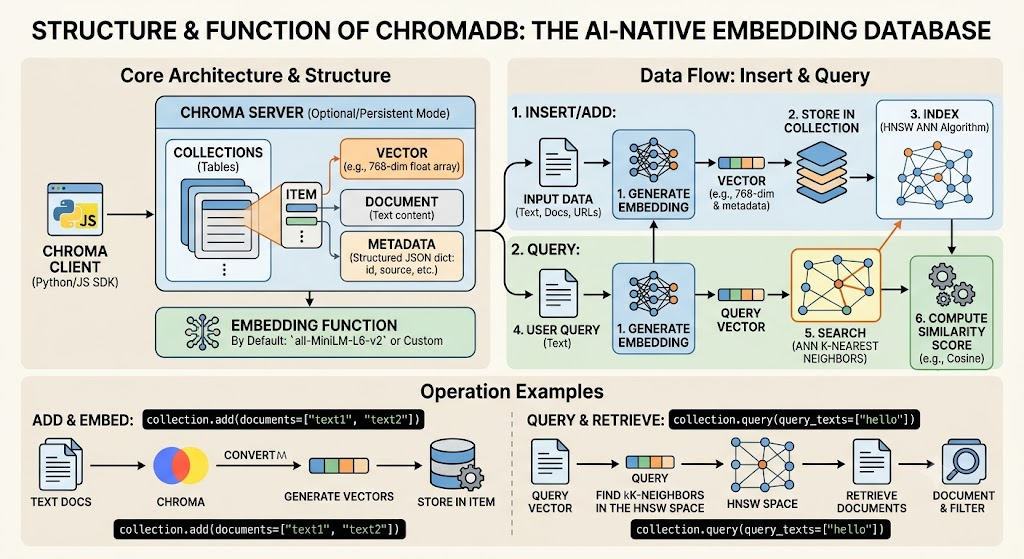

<br>

**ChromaDB** permite inicializarse de tres formas distintas:

- Modo Efimero
Pensado para cargar todo el sistema en memoria RAM

- Modo Persistente
Este metodo permite persistir los datos mediante la escritura en archivo de disco

- Conexión HTTP
Este metodo permite trabajar sobre una conexión remota en modo cliente/servidor.



<br>

## EMPEZANDO CON CHROMADB

Luego de instalar el paquete de chromadb empezaremos a trabajar

<br>

-------------

>INSTALAMOS (pip install chromadb)

>IMPORTAMOS (import chromadb)

>INSTANCIAMOS (chromadb.Client())

-------------

<br>

Con estos pasos ya tenemos la estructura minima para trabajar, ahora siguen los pasos minimos necesarios para crear los datos

>CREAR COLECCION (chroma_client.create_collection(name="mi_coleccion"))

>AGREGAR DOCUMENTOS (collection.add(ids="id1",documents=["Este texto es un documento"]))

>CONSULTAR COLECCION (CONSULTAR COLECCION(collection.query(query_texts=["Esto es un texto para comparar"]))



<br>

### PRIMEROS PASOS
Repasando los pasos primero realizamos la instalación en nuestro entorno del paquete chromadb, lo importamos para poder ejecutarlo.

Creamos el objeto **chroma_client = chromadb.Client()**

Ya con el cliente creado pasamos a crear una colección, una colección se puede comparar con una tabla de bases relacionales, podemos tener en una instancia de chromadb N cantidad de colecciones con distintos nombres.


<br>

### MODELOS DE EMBEDDINGS

Al definir una colección se puede definir el modelo de embedding que se va a utilizar, es decir que la tecnica/modelo de embedding sera la misma para toda la colección seleccionada

Por defecto Chromadb va a utilizar el modelo **all-MiniLM-L6-v2** de la librería Sentence Transformers (desarrollada por Hugging Face) - Tener en cuenta que esto puede cambiar y es información al dia de hoy Junio/26

Igualmente es posible indicarle a ChromaDB que utilice el modelo que nosotros querramos, teniendo en cuenta los requerimientos que cada modelo pueda tener, en el caso de OpenAI , como ejemplo, nos requiere una API Key

<br>

```
import os
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

collection = client.create_collection(
    name="my_collection",
    embedding_function=OpenAIEmbeddingFunction(
        api_key=os.getenv("OPENAI_API_KEY"),
        model_name="text-embedding-3-small"
    )
)

```

<br>

Por otro lado podriamos asignarle otros modelos mas adecuados para nuestro uso particular, por ejemplo un modelo que funcione mejor para el español

<br>

```
from chromadb.utils import embedding_functions

#  Definimos la función de embedding multilingüe
función_multilingue = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="paraphrase-multilingual-MiniLM-L12-v2"
)

#  Se la pasamos a la colección al momento de crearla
coleccion = client.get_or_create_collection(
    name="datos_carrera_espanol",
    embedding_function=función_multilingue # <--- Reemplaza al modelo por defecto
)
```

<br>


Vamos a encontrarnos en algunos casos el metodo ***get_or_create_collection***  y en otros casos ***create_collection***, la diferencia entre ellas es que la primera valida si existe la coleccion y sino la crea, la segunda opción solamente acepta la creación de la colección si es que no existe.

Existe una tercer opción y es que los datos que tenemos ya pasaron por un proceso de creación de embeddings, por lo cual no queremos que ChromaDB le aplique ninguna función a nuestros documentos. Para esto tenemos la opción de omitir.

<br>

```
collection = client.create_collection(
    name="my_collection",
    embedding_function=None
)
```

-------------

<br>
<br>

### METADATA EN COLECCION

ChromaDB nos da la posibilidad de guardar, junto a nuestra colección, metadata que sirva de referencia y de identificación.

<br>


```
from datetime import datetime

collection = client.create_collection(
    name="my_collection",
    embedding_function=emb_fn,
    metadata={
        "description": "Estos datos pueden servir para identificar la colección",
        "created": str(datetime.now())
    }
)
```

<br>

Podriamos revisar cuales son las colecciones creadas con el metodo:
> client.list_collections()

<br>

Podemos eliminar una colección:

>client.delete_collection(name="my-collection")

<br>

Una vez que ya tenemos el objeto coleccion (sea porque lo creamos o porque lo buscamos), podemos realizar un conteo de cantidad de documentos/registros

>collection.count()

<br>

Mostrar los primeros 10 registros
>collection.peek()
<br>
----------

<br>

### AGREGAR DOCUMENTOS

Para empezar a agregar los documentos vamos a usar el metodo **.add()**


Vamos a ver un caso de add de un solo elemento y luego como trabajarlo como lista de diccionarios

<br>

#####CARGA DE UN ELEMENTO
```
collection.add(
    ids=["id1"],
    documents=["lorem ipsum..."],
    metadatas=[{"chapter": 3, "verse": 16}],
)

```
Vemos que al agregar un elemento/registro, debemos definir como MINIMO un id y el documento, se puede de igualmanera sumar información de metadatos en forma de diccionario.

Es importante destacar que la carga de elementos requiere que esten enmarcados en listas aunque el elemento a cargar sea uno solo.

<br>

#####CARGA DE VARIOS ELEMENTOS

<br>

```
collection.add(
    ids=["id1", "id2", "id3"],
    documents=["lorem ipsum...", "doc2", "doc3"],
    metadatas=[{"chapter": 3, "verse": 16}, {"chapter": 3, "verse": 5}, {"chapter": 29, "verse": 11}],
)
```

####ACTUALIZACION DE ELEMENTOS

<br>

Tenemos dos metodos para actualizar un registro:

<br>

- collection.update  (Actualiza si existe)

- collection.upsert (Actualiza o Crea)

<br>

####ELIMINAR UN REGISTRO

<br>

- collection.delete(ids=["id1"],) (eliminar elemento a partir del ids)

<br>

Tambien podemos eliminar segun condicion

- collection.delete(where={"chapter": "20"}) (Donde chapter es un metadatas)

<br>



### CONFIGURACIONES ADICIONALES EN LAS COLECCIONES

<br>

Como ya se comento anteriormente ChromaDB utiliza como mecanismo de indexación **HNSW** (Hierarchical Navigable Small World), esto permite el uso de las **ANN**.




La indexación por HNSW tiene los parametros:

<br>

>>> ***space***

Es la metrica con la cual se va a calcular la distancia entre los vectores

<br>

Tenemos a disposición
<br>
- l2 (distancia euclidea)

- ip (producto punto o escalar)

- cosine (coseno)

<br>

>>> ***ef_construction***

Determina la cantidad de candidatos considerados al modelar con ANN, un valor  alto implica mejor calidad pero mayor valor computacional
El valor por defecto es 100

<br>

>>> ***ef_search***

Durante la etapa de BUSQUEDA (es decir luego de ya haber generado el modelo de ANN) el ef_search determina la cantidad de candidatos que se analizan en cada bloque de busqueda, un valor mas alto mejorara la calidad de busqueda y podria dar un mejor aproximado, teniendo en contraprestación mayor consumo de memoria y tiempo.
El valor por defecto es 100

<br>

>>> ***max_neighbors***

Es la maxima cantidad de vecinos que cada nodo puede aceptar durante la construcción del indice, mayor el valor implica una mejora en recall y accuracy.

El valor por defecto es 16.


<br>

------------------------
| Característica | `max_neighbors` (M) | `ef_construction` |
| :--- | :--- | :--- |
| **Fase en la que actúa** | Construcción e Índice Final (Estructura fija). | Únicamente durante la construcción (`.add()` / `.upsert()`). |
| **¿Qué limita?** | El número de enlaces físicos por nodo. | La profundidad de la búsqueda para encontrar esos enlaces. |
| **Impacto en RAM/Disco** | **Alto**. A mayor valor, el archivo del índice pesa significativamente más. | **Nulo**. No afecta el tamaño final del índice en memoria. |
| **Impacto en velocidad de inserción** | Bajo/Moderado. | **Muy Alto**. Valores grandes ralentizan drásticamente la carga de datos. |
| **Impacto en precisión de búsqueda** | Ayuda a separar clusters complejos de alta dimensión. | Aumenta la calidad del grafo, reduciendo falsos negativos en búsquedas. |
---------------

<br>

Otros parametros disponibles que se pueden utilizar:

num_threads : Threads a utilizar en las busquedas y la creación del indice

batch_size : Cantidad de vectores que se analizan por bloque

resize_factor :  Porcentaje de crecimiento maximo del indice al regenerarse


<br>

Podemos ver un ejemplo de uso del parametro **configuration**  que toma un diccionario donde uno de los elementos es **hnsw** que tambien es un diccionario.

<br>


```
collection = client.create_collection(
    name="my-collection",
    embedding_function=OpenAIEmbeddingFunction(model_name="text-embedding-3-small"),
    configuration={
        "hnsw": {
            "space": "cosine",
            "ef_construction": 200
        }
    }
)
```

### BUSQUEDA

ChromaDB permite dos tipos de busqueda, una exclusiva para metadatos y otra flexible que permite buscar por similitud o por similitud + metadatos

```
collection.query(
    query_texts=["thus spake zarathustra", "the oracle speaks"])
```
<br>


Eventualmente podriamos haber guardado directamente los vectores sin pasar por un modelo de embeddings gestionado por ChromaDB, en este caso podriamos pasarle los vectores de forma

<br>

>>collection.query(query_embeddings=[[11.1, 12.1, 13.1], [1.1, 2.3, 3.2]])

<br>

Por otro lado tenemos la busqueda por get


>>collection.get(altura:[310])

<br>

#### BUSQUEDAS ESPECIALES

<br>


Podemos usar operadores especiales como AND,OR,IN,CONTAINS,NOT IN, NOT CONTAINS, y operadores matematicos como mayor, menor, mayor o igual, etc.

<br>

------------------

```
collection.query(
    query_texts=["first query", "second query"],
    where={
        "$and": [
            {"page": {"$gte": 5 }},
            {"page": {"$lte": 10 }},
        ]
    }
)
```
------------------

<br>

Como podemos ver los operadores AND|OR|NOT|etc ingresan como elementos de un diccionario del elemento where, donde sus valores seran una lista de diccionarios.



## MODO PERSISTENTE

Vimos anteriormente como podemos trabajar con una base vectorial alojada en la ram, la cual al finalizar de ejecutarse se eliminaran todos los datos.

Los metodos y la tecnica de trabajo para poder persistir los datos de una sesión a otra no es muy distinta, lo unico que vamos a cambiar es al instanciar el objeto que llamamos cliente

<br>

```
client = chromadb.PersistentClient(path="./mi_base_de_datos")
```

<br>

Aqui vamos a tener la llamada al metodo PersistentClient() el cual define que nuestra conexión va a ser a una base de datos persistente. Luego tendremos para definir el path a donde vamos a alojar o donde ya esta alojada nuestra base vectorial.

<br>

Si queremos trabajar sobre una base que ya esta creada solo debemos incluir el path al directorio donde esta y seguir a partir de ese punto trabajando como ya habiamos visto antes.

<br>

Por detras lo que va a suceder es que ChromaDB creara una base SQLite para poder gestionar de forma persistente los datos.

<br>

-----------
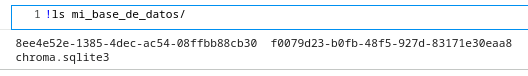

-------------

<br>

Cuando inicializás un cliente persistente, ChromaDB crea una estructura de archivos optimizada en la ruta indicada.

Si inspeccionás esa carpeta en tu sistema operativo, vas a encontrar principalmente esto:

<br>
***chroma.sqlite3***: Chroma utiliza SQLite internamente como motor relacional para gestionar los metadatos de las colecciones, las rutas, los textos planos (documents) y la configuración general.

<br>

***Archivos de Índice Binarios***: Vas a ver una serie de archivos de datos binarios (o subcarpetas con identificadores largos).

Ahí es donde se almacena físicamente el índice HNSW (los grafos espaciales con los vectores matemáticos). Estos archivos están optimizados para lectura y escritura a nivel de bits.

<br>


Podemos ver un notebook de ejemplos:

<br>

[Ejemplo ChromaDB](https://colab.research.google.com/drive/1cSxGfMByEsMH-jOYlwNq9zJ9iHxdoLRz?usp=sharing)

<br>

-----------------

-----------

>Si te quedan preguntas no dudes en contactarme
>>>arielmeragelman@gmail.com

>>>Lic. Sebastian A. Meragelman